In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pickle
import json

In [2]:
parent_path = '..'

In [3]:
# Load Model
model = tf.keras.models.load_model(f'{parent_path}/models/best_model.h5')

In [4]:
# Load test data
test_data = np.load(f'{parent_path}/data/processed/test_data.npz')
X_test = test_data['X'] 
y_test = test_data['y']

In [5]:
X_test.shape, y_test.shape

((746, 224, 224, 3), (746,))

In [6]:
# Get Prediction
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step


In [7]:
y_pred_proba[0],y_pred[0], y_test[0]

(array([3.63987221e-18, 5.48126558e-22, 7.55746843e-09, 1.98507902e-20,
        8.22722034e-23, 1.14468484e-27, 9.99999762e-01, 2.57735665e-18,
        6.33856616e-23, 4.23205700e-22, 4.81465080e-21, 1.29647927e-20,
        1.29044811e-30, 1.46033372e-07, 1.20680266e-08, 1.38519894e-07,
        1.61506530e-27, 6.12177777e-28, 2.87776906e-28, 2.37666323e-27,
        1.39678435e-27, 1.05267178e-28, 7.90269053e-23, 2.53603501e-17],
       dtype=float32),
 np.int64(6),
 np.int64(6))

In [8]:
# Calculate metrics
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9946


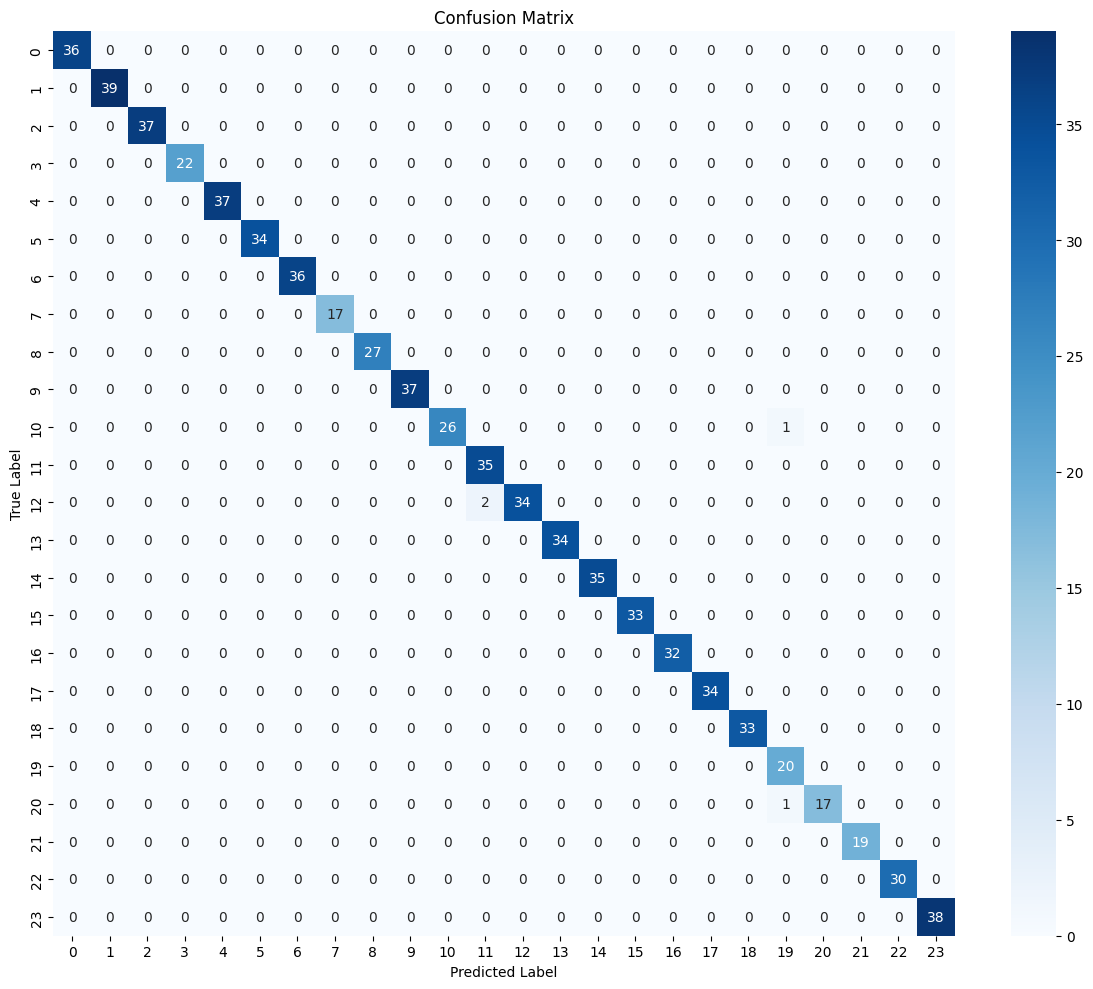

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{parent_path}/results/confusion_matrix.png', dpi=300)
plt.show()
plt.close()

In [10]:
# Classification Report
with open(f'{parent_path}/data/processed/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)


              precision    recall  f1-score   support

           A       1.00      1.00      1.00        36
           B       1.00      1.00      1.00        39
           C       1.00      1.00      1.00        37
           D       1.00      1.00      1.00        22
           E       1.00      1.00      1.00        37
           F       1.00      1.00      1.00        34
           G       1.00      1.00      1.00        36
           H       1.00      1.00      1.00        17
           I       1.00      1.00      1.00        27
           K       1.00      1.00      1.00        37
           L       1.00      0.96      0.98        27
           M       0.95      1.00      0.97        35
           N       1.00      0.94      0.97        36
           O       1.00      1.00      1.00        34
           P       1.00      1.00      1.00        35
           Q       1.00      1.00      1.00        33
           R       1.00      1.00      1.00        32
           S       1.00    

In [12]:
with open(f'{parent_path}/results/classification_report.txt', 'w') as f:
    f.write(report)

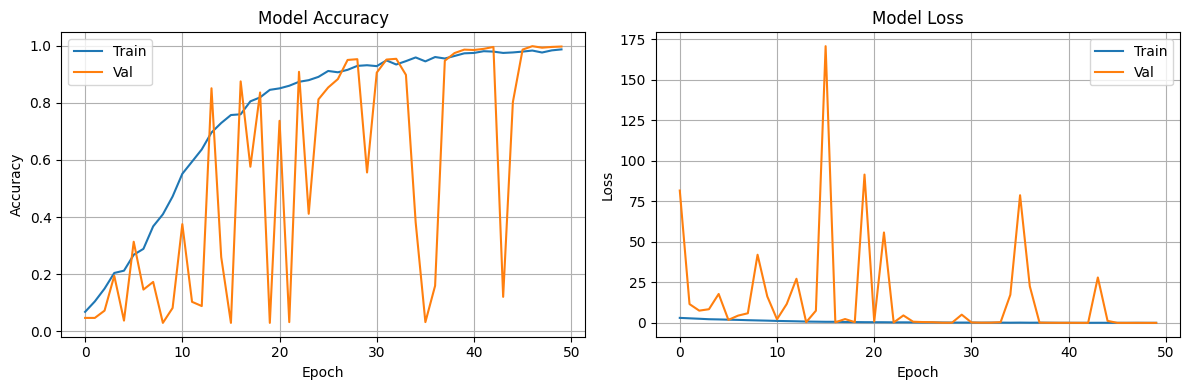

In [13]:
with open(f'{parent_path}/results/training_history.json', 'r') as f:
    history = json.load(f)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f'{parent_path}/results/training_curves.png', dpi=300)
plt.show()
plt.close()